# Seelig A5SS SD1 Pretraining HPO Decision, May 2026

This notebook reviews the BODA intron pretraining HPO on the Rosenberg / Patwardhan / Shendure / Seelig 2015 alternative 5' splice-site library.

Scope:

- Task: A5SS scalar donor-1 usage, `p_sd1`.
- Model family: scratch `BassetBranched` with one scalar output.
- Selection rule: choose the canonical pretrained artifact by validation/checkpoint metric, `epoch_end_val_pearson_r2`; use held-out test metrics only as critique.
- Literature guardrail: Rosenberg et al. report the HAL splice-donor model explains `R2 = 0.75` for SD1, `0.75` for SD2, `0.54` for SDCRYPT, and `0.83` for new donor-site usage in cross-validation (Cell 2015, Figure 5A; DOI `10.1016/j.cell.2015.09.054`).

Plain-language target read: this is not an expression signal in the promoter/enhancer sense. The target is splice choice from read counts. `p_sd1` means `SD1 reads / total spliced reads` for an A5SS construct, so the one-output model predicts the fraction of reads using splice donor 1.

Metric-language read: the checkpoint monitor and the notebook's legacy `*_r2` columns are Pearson correlation squared. COD R2 is logged separately as `*_cod_r2` in W&B summaries when available, and should be kept separate from Pearson-squared in future comparisons.

Important comparison caveat: our run is a scalar `p_sd1` CNN on the BODA train/val/test split, while the paper's HAL result is a cross-validated additive 6-mer model over the richer donor distribution task. The SD1 value is still the right first guardrail for the scalar smoke/pretraining task, but it is not a perfect apples-to-apples benchmark.


In [1]:
from pathlib import Path
import json
import math
import os
import re
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

WORK_ROOT = Path("/home/minhang/synBio_AL")
REPO_ROOT = WORK_ROOT / "boda2_EU"
LEARN_ROOT = REPO_ROOT / "src" / "learn"
RUNS_CSV = LEARN_ROOT / "run_registry" / "runs.csv"
SWEEP_LAUNCHES_CSV = LEARN_ROOT / "run_registry" / "sweep_launches.csv"
WANDB_ROOT = LEARN_ROOT / "wandb"
DATA_ROOT = WORK_ROOT / "opt_EU_learn_n_design" / "introns" / "seelig_2015"
DATA_PATH = DATA_ROOT / "A5SS_scalar_targets.csv"
MANIFEST_PATH = DATA_ROOT / "manifest.json"
PLOT_DIR = REPO_ROOT / "tutorials" / "lib1_tasks" / "pretraining_CRE_public_data" / "presentation_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

COMPARISON_GROUP = "introns__seelig_2015_a5ss_sd1__scratch_basset_branched"
PROJECT = "introns__seelig_2015_a5ss_sd1__scratch__basset_branched"
SWEEP_ID = "zp03wzup"
AUTHOR_SD1_R2 = 0.75
SOURCE_DOI = "https://doi.org/10.1016/j.cell.2015.09.054"
SOURCE_CODE = "https://github.com/Alex-Rosenberg/cell-2015"


## Load HPO Runs

The registry is treated as the authoritative source for run selection. Local W&B summaries/configs are used only for additional diagnostics and hyperparameter context.


In [2]:
numeric_cols = [
    "best_epoch", "best_metric_value", "val_loss", "val_r2", "val_pearson", "val_spearman",
    "test_loss", "test_r2", "test_pearson", "test_spearman",
    "train_loss", "train_r2", "train_pearson", "train_spearman",
]

runs = pd.read_csv(RUNS_CSV)
for col in numeric_cols:
    if col in runs.columns:
        runs[col] = pd.to_numeric(runs[col], errors="coerce")
runs["timestamp"] = pd.to_datetime(runs["timestamp"], errors="coerce")

candidates = runs[runs["comparison_group"].eq(COMPARISON_GROUP)].copy()
candidates["artifact_exists"] = candidates["artifact_path"].map(lambda value: bool(isinstance(value, str) and Path(value).exists()))
candidates["train_pearson_r2"] = candidates["train_pearson"] ** 2
candidates["val_minus_test_r2"] = candidates["best_metric_value"] - candidates["test_r2"]
candidates["train_minus_val_pearson_r2"] = candidates["train_pearson_r2"] - candidates["best_metric_value"]
candidates["phase"] = np.where(candidates["timestamp"] < pd.Timestamp("2026-05-17"), "pilot_8", "expanded_32")

print(f"Loaded {len(candidates)} Seelig A5SS SD1 candidate runs from {RUNS_CSV}")
display(
    candidates.groupby(["phase", "status"], observed=True)
    .agg(
        n_runs=("run_id", "size"),
        artifacts_present=("artifact_exists", "sum"),
        best_val_metric=("best_metric_value", "max"),
        median_val_metric=("best_metric_value", "median"),
        best_test_r2=("test_r2", "max"),
        median_test_r2=("test_r2", "median"),
    )
    .reset_index()
    .round(4)
)

if candidates.empty:
    raise RuntimeError(f"No runs found for comparison_group={COMPARISON_GROUP}")


Loaded 40 Seelig A5SS SD1 candidate runs from /home/minhang/synBio_AL/boda2_EU/src/learn/run_registry/runs.csv


,phase,status,n_runs,artifacts_present,best_val_metric,median_val_metric,best_test_r2,median_test_r2
0,expanded_32,completed,32,32,0.8032,0.7598,0.8006,0.7588
1,pilot_8,completed,8,8,0.7999,0.7557,0.7956,0.7506


## Dataset Split And Target Sanity Check

This section verifies the exact materialized dataset used for HPO. The scalar target is `p_sd1 = SD1 reads / total reads` after filtering to A5SS designs with at least one read.


In [3]:
if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text())
    display(pd.DataFrame(manifest.get("libraries", [])))
else:
    print(f"Missing manifest: {MANIFEST_PATH}")

if DATA_PATH.exists():
    data = pd.read_csv(DATA_PATH, usecols=["fold", "p_sd1", "p_sd2_conditional", "read_count_total"])
    split_summary = (
        data.groupby("fold", observed=True)
        .agg(
            n=("p_sd1", "size"),
            p_sd1_mean=("p_sd1", "mean"),
            p_sd1_median=("p_sd1", "median"),
            p_sd1_std=("p_sd1", "std"),
            reads_median=("read_count_total", "median"),
            reads_mean=("read_count_total", "mean"),
        )
        .reset_index()
    )
    display(split_summary.round(4))
    split_summary.to_csv(PLOT_DIR / "seelig_a5ss_sd1_dataset_split_summary_may2026.csv", index=False)
else:
    print(f"Missing data file: {DATA_PATH}")
    data = pd.DataFrame()


,library,n_rows,source_rows,min_reads,target_columns,fold_counts,output_path,distribution_path
0,A5SS,265044,265137,1,"[p_sd1, p_sd2_conditional]","{'test': 26504, 'train': 212036, 'val': 26504}",/home/minhang/synBio_AL/opt_EU_learn_n_design/introns/seelig_2015/A5SS_scalar_targets.csv,


,fold,n,p_sd1_mean,p_sd1_median,p_sd1_std,reads_median,reads_mean
0,test,26504,0.2240,0.0526,0.3073,44.0,51.0145
1,train,212036,0.2239,0.0526,0.3081,44.0,49.9201
2,val,26504,0.2221,0.0500,0.3075,43.0,49.8230


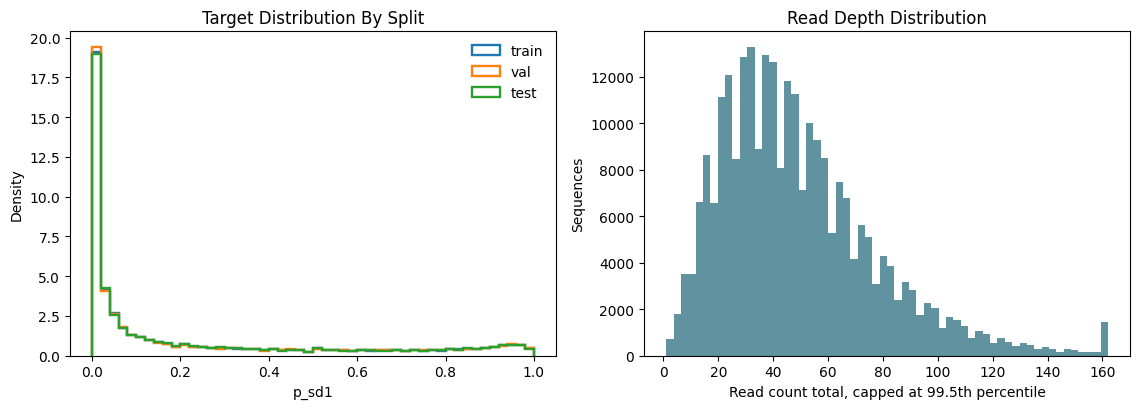

In [4]:
if not data.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
    fold_order = [fold for fold in ["train", "val", "test"] if fold in set(data["fold"])]
    for fold in fold_order:
        sub = data[data["fold"].eq(fold)]
        axes[0].hist(sub["p_sd1"], bins=50, histtype="step", density=True, linewidth=1.7, label=fold)
    axes[0].set_xlabel("p_sd1")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Target Distribution By Split")
    axes[0].legend(frameon=False)

    capped_reads = data["read_count_total"].clip(upper=data["read_count_total"].quantile(0.995))
    axes[1].hist(capped_reads, bins=60, color="#3D7A8A", alpha=0.82)
    axes[1].set_xlabel("Read count total, capped at 99.5th percentile")
    axes[1].set_ylabel("Sequences")
    axes[1].set_title("Read Depth Distribution")
    fig.tight_layout()
    fig.savefig(PLOT_DIR / "seelig_a5ss_sd1_dataset_sanity_may2026.png", dpi=180, bbox_inches="tight")
    plt.show()


## Sweep Health

A good HPO result should have a recoverable artifact, a plausible distribution of scores, and validation rankings that carry over to held-out test metrics.


In [5]:
def _spearman(frame, left, right):
    sub = frame[[left, right]].dropna()
    if len(sub) < 2:
        return np.nan
    return sub[left].corr(sub[right], method="spearman")

health = pd.DataFrame([
    {
        "n_runs": len(candidates),
        "completed_runs": int(candidates["status"].eq("completed").sum()),
        "artifacts_present": int(candidates["artifact_exists"].sum()),
        "near_zero_runs": int(candidates["best_metric_value"].fillna(0).lt(0.01).sum()),
        "best_val_metric": candidates["best_metric_value"].max(),
        "median_val_metric": candidates["best_metric_value"].median(),
        "best_test_r2": candidates["test_r2"].max(),
        "median_test_r2": candidates["test_r2"].median(),
        "best_test_pearson": candidates["test_pearson"].max(),
        "best_test_spearman": candidates["test_spearman"].max(),
        "val_test_rank_spearman": _spearman(candidates, "best_metric_value", "test_r2"),
        "median_val_minus_test_r2": candidates["val_minus_test_r2"].median(),
        "median_train_minus_val_pearson_r2": candidates["train_minus_val_pearson_r2"].median(),
    }
])
display(health.round(4))
health.to_csv(PLOT_DIR / "seelig_a5ss_sd1_hpo_health_may2026.csv", index=False)


,n_runs,completed_runs,artifacts_present,near_zero_runs,best_val_metric,median_val_metric,best_test_r2,median_test_r2,best_test_pearson,best_test_spearman,val_test_rank_spearman,median_val_minus_test_r2,median_train_minus_val_pearson_r2
0,40,40,40,4,0.8032,0.7593,0.8006,0.7573,0.8947,0.8102,0.9974,0.0022,0.082


In [6]:
top_cols = [
    "run_id", "phase", "best_metric_value", "val_pearson", "test_r2", "test_pearson",
    "test_spearman", "train_pearson_r2", "best_epoch", "artifact_exists", "run_url", "artifact_path",
]
leaderboard = candidates.sort_values(["best_metric_value", "timestamp"], ascending=[False, False])[top_cols].copy()
display(leaderboard.head(15).round(4))
leaderboard.to_csv(PLOT_DIR / "seelig_a5ss_sd1_hpo_leaderboard_may2026.csv", index=False)


,run_id,phase,best_metric_value,val_pearson,test_r2,test_pearson,test_spearman,train_pearson_r2,best_epoch,artifact_exists,run_url,artifact_path
742,hcs3zprb,expanded_32,0.8032,0.8928,0.8006,0.8947,0.7980,0.8308,52,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/hcs3zprb,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...
731,vnr1wmxj,pilot_8,0.7999,0.8924,0.7956,0.8920,0.7962,0.8224,25,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/vnr1wmxj,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...
725,qcgatoln,pilot_8,0.7951,0.8754,0.7934,0.8907,0.8102,0.8400,4,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/qcgatoln,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...
752,e7jcjjqa,expanded_32,0.7895,0.8756,0.7885,0.8880,0.7869,0.8381,6,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/e7jcjjqa,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...
735,s7h1tvab,expanded_32,0.7840,0.8673,0.7799,0.8831,0.8029,0.8455,5,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/s7h1tvab,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...
754,zpbfj2tt,expanded_32,0.7836,0.8709,0.7814,0.8840,0.7866,0.8439,8,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/zpbfj2tt,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...
753,wrut9yrz,expanded_32,0.7827,0.8564,0.7809,0.8837,0.7786,0.8379,6,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/wrut9yrz,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...
726,rhyyvqsb,pilot_8,0.7824,0.8745,0.7770,0.8815,0.7682,0.8507,11,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/rhyyvqsb,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...
737,gxlo1ec6,expanded_32,0.7810,0.8730,0.7809,0.8837,0.7896,0.8381,15,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/gxlo1ec6,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...
743,4a7atbds,expanded_32,0.7804,0.8627,0.7763,0.8811,0.7860,0.8421,10,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/4a7atbds,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...


## Validation Winner And Test Critique

The official pretrained model choice follows the checkpoint monitor. Test leaders are shown only to critique the decision.


In [7]:
def best_by(frame, metric, ascending=False):
    usable = frame.dropna(subset=[metric]).copy()
    return usable.sort_values([metric, "timestamp"], ascending=[ascending, False]).iloc[0]

validation_winner = best_by(candidates, "best_metric_value", ascending=False)
test_r2_leader = best_by(candidates, "test_r2", ascending=False)
test_spearman_leader = best_by(candidates, "test_spearman", ascending=False)

winner_rows = []
for label, row in [
    ("validation_selected", validation_winner),
    ("test_r2_leader", test_r2_leader),
    ("test_spearman_leader", test_spearman_leader),
]:
    winner_rows.append({
        "role": label,
        "run_id": row["run_id"],
        "best_metric_name": row["best_metric_name"],
        "best_metric_value": row["best_metric_value"],
        "val_pearson": row["val_pearson"],
        "test_r2": row["test_r2"],
        "test_pearson": row["test_pearson"],
        "test_spearman": row["test_spearman"],
        "best_epoch": row["best_epoch"],
        "artifact_exists": row["artifact_exists"],
        "run_url": row["run_url"],
        "artifact_path": row["artifact_path"],
    })
winners = pd.DataFrame(winner_rows)
display(winners.round(4))
winners.to_csv(PLOT_DIR / "seelig_a5ss_sd1_hpo_winners_may2026.csv", index=False)

same_test_r2 = validation_winner["run_id"] == test_r2_leader["run_id"]
same_spearman = validation_winner["run_id"] == test_spearman_leader["run_id"]
print(f"Validation winner also test-R2 leader: {same_test_r2}")
print(f"Validation winner also test-Spearman leader: {same_spearman}")


,role,run_id,best_metric_name,best_metric_value,val_pearson,test_r2,test_pearson,test_spearman,best_epoch,artifact_exists,run_url,artifact_path
0,validation_selected,hcs3zprb,epoch_end_val_pearson_r2,0.8032,0.8928,0.8006,0.8947,0.7980,52,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/hcs3zprb,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...
1,test_r2_leader,hcs3zprb,epoch_end_val_pearson_r2,0.8032,0.8928,0.8006,0.8947,0.7980,52,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/hcs3zprb,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...
2,test_spearman_leader,qcgatoln,epoch_end_val_pearson_r2,0.7951,0.8754,0.7934,0.8907,0.8102,4,True,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/qcgatoln,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__b...


Validation winner also test-R2 leader: True
Validation winner also test-Spearman leader: False


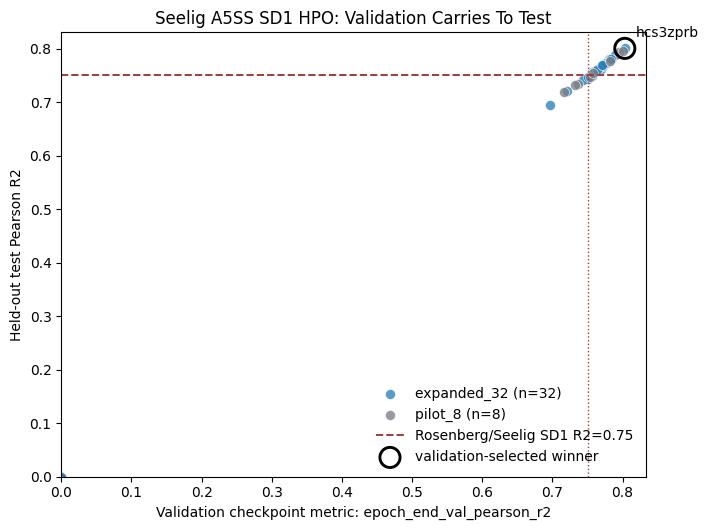

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 5.4))
phase_colors = {"pilot_8": "#7A7F87", "expanded_32": "#2C7FB8"}
for phase, sub in candidates.groupby("phase", observed=True):
    ax.scatter(
        sub["best_metric_value"], sub["test_r2"],
        s=52, alpha=0.78, label=f"{phase} (n={len(sub)})",
        color=phase_colors.get(phase, "#444444"), edgecolor="white", linewidth=0.5,
    )
ax.axhline(AUTHOR_SD1_R2, color="#A23B3B", linestyle="--", linewidth=1.4, label="Rosenberg/Seelig SD1 R2=0.75")
ax.axvline(AUTHOR_SD1_R2, color="#A23B3B", linestyle=":", linewidth=1.0)
ax.scatter(
    [validation_winner["best_metric_value"]], [validation_winner["test_r2"]],
    s=210, facecolors="none", edgecolors="black", linewidths=2.1, label="validation-selected winner",
)
ax.annotate(
    validation_winner["run_id"],
    (validation_winner["best_metric_value"], validation_winner["test_r2"]),
    xytext=(8, 8), textcoords="offset points", fontsize=10,
)
ax.set_xlabel("Validation checkpoint metric: epoch_end_val_pearson_r2")
ax.set_ylabel("Held-out test Pearson R2")
ax.set_title("Seelig A5SS SD1 HPO: Validation Carries To Test")
ax.set_xlim(left=max(0, candidates["best_metric_value"].min() - 0.04), right=min(0.86, candidates["best_metric_value"].max() + 0.03))
ax.set_ylim(bottom=max(0, candidates["test_r2"].min() - 0.04), top=min(0.86, candidates["test_r2"].max() + 0.03))
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(PLOT_DIR / "seelig_a5ss_sd1_val_vs_test_may2026.png", dpi=200, bbox_inches="tight")
plt.show()


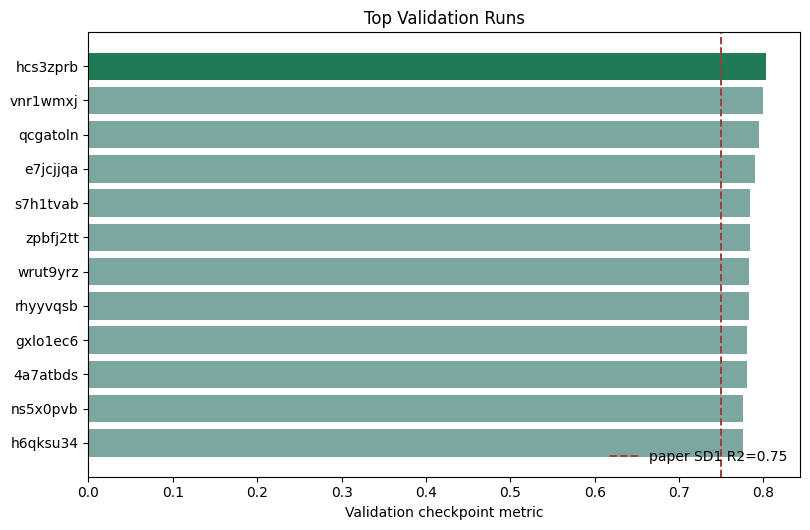

In [9]:
plot_df = candidates.sort_values("best_metric_value", ascending=False).head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.2, 5.4))
colors = ["#1F7A56" if rid == validation_winner["run_id"] else "#7BA7A0" for rid in plot_df["run_id"]]
ax.barh(plot_df["run_id"], plot_df["best_metric_value"], color=colors)
ax.axvline(AUTHOR_SD1_R2, color="#A23B3B", linestyle="--", linewidth=1.4, label="paper SD1 R2=0.75")
ax.set_xlabel("Validation checkpoint metric")
ax.set_title("Top Validation Runs")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(PLOT_DIR / "seelig_a5ss_sd1_top_validation_runs_may2026.png", dpi=200, bbox_inches="tight")
plt.show()


## Comparison To Author-Reported HAL Performance

This is the most useful high-level readout. The scalar BODA checkpoint is compared to the paper's reported SD1 donor-fraction `R2 = 0.75`. Rows for SD2, SDCRYPT, and SDNEW are included to keep the broader HAL context visible; those targets were not trained in this scalar HPO.


In [10]:
author_report = pd.DataFrame([
    {"target": "SD1 donor fraction", "paper_reported_r2": 0.75, "boda_metric": "test_r2 for p_sd1", "boda_value": float(validation_winner["test_r2"]), "status": "direct scalar guardrail"},
    {"target": "SD2 donor fraction", "paper_reported_r2": 0.75, "boda_metric": "not trained", "boda_value": np.nan, "status": "future 81-output distribution task"},
    {"target": "SDCRYPT donor fraction", "paper_reported_r2": 0.54, "boda_metric": "not trained", "boda_value": np.nan, "status": "future 81-output distribution task"},
    {"target": "new donor-site usage", "paper_reported_r2": 0.83, "boda_metric": "not trained", "boda_value": np.nan, "status": "future 81-output distribution task"},
])
author_report["boda_minus_paper"] = author_report["boda_value"] - author_report["paper_reported_r2"]
author_report["source"] = "Rosenberg et al. Cell 2015 Figure 5A; DOI 10.1016/j.cell.2015.09.054"
display(author_report.round(4))
author_report.to_csv(PLOT_DIR / "seelig_a5ss_sd1_author_comparison_may2026.csv", index=False)

print(
    f"Validation-selected BODA run {validation_winner['run_id']} reaches test R2 "
    f"{validation_winner['test_r2']:.4f}, which is {validation_winner['test_r2'] - AUTHOR_SD1_R2:+.4f} "
    "relative to the paper's reported SD1 R2=0.75 guardrail."
)


,target,paper_reported_r2,boda_metric,boda_value,status,boda_minus_paper,source
0,SD1 donor fraction,0.75,test_r2 for p_sd1,0.8006,direct scalar guardrail,0.0506,Rosenberg et al. Cell 2015 Figure 5A; DOI 10.1016/j.cell.2015.09.054
1,SD2 donor fraction,0.75,not trained,NaN,future 81-output distribution task,NaN,Rosenberg et al. Cell 2015 Figure 5A; DOI 10.1016/j.cell.2015.09.054
2,SDCRYPT donor fraction,0.54,not trained,NaN,future 81-output distribution task,NaN,Rosenberg et al. Cell 2015 Figure 5A; DOI 10.1016/j.cell.2015.09.054
3,new donor-site usage,0.83,not trained,NaN,future 81-output distribution task,NaN,Rosenberg et al. Cell 2015 Figure 5A; DOI 10.1016/j.cell.2015.09.054


Validation-selected BODA run hcs3zprb reaches test R2 0.8006, which is +0.0506 relative to the paper's reported SD1 R2=0.75 guardrail.


## Hyperparameter Context

The W&B sweep config files are local under `src/learn/wandb/sweep-zp03wzup/config-<run_id>.yaml`. This section parses them without requiring PyYAML so the notebook stays runnable in a lightweight environment.


In [ ]:
def _parse_scalar(text):
    text = text.strip()
    if text in {"true", "True"}:
        return True
    if text in {"false", "False"}:
        return False
    if text in {"None", "null", ""}:
        return None
    if (text.startswith('"') and text.endswith('"')) or (text.startswith("'") and text.endswith("'")):
        return text[1:-1]
    try:
        if re.search(r"[.eE]", text):
            return float(text)
        return int(text)
    except Exception:
        return text

def load_wandb_config(run_id):
    path = WANDB_ROOT / f"sweep-{SWEEP_ID}" / f"config-{run_id}.yaml"
    if not path.exists():
        return {"run_id": run_id, "config_path": str(path), "config_exists": False}
    data = {"run_id": run_id, "config_path": str(path), "config_exists": True}
    current_key = None
    for raw in path.read_text().splitlines():
        line = raw.rstrip("\n")
        stripped = line.strip()
        if not stripped or stripped.startswith("wandb_version"):
            continue
        if not line.startswith(" ") and stripped.endswith(":"):
            current_key = stripped[:-1]
            continue
        if current_key is None:
            continue
        if stripped.startswith("value:"):
            value_text = stripped[len("value:"):].strip()
            data[current_key] = _parse_scalar(value_text) if value_text else []
        elif stripped.startswith("- "):
            data.setdefault(current_key, [])
            if not isinstance(data[current_key], list):
                data[current_key] = [data[current_key]]
            data[current_key].append(_parse_scalar(stripped[2:]))
    return data

configs = pd.DataFrame([load_wandb_config(run_id) for run_id in candidates["run_id"]])
config_cols = [
    "run_id", "config_exists", "batch_size", "optimizer", "lr", "weight_decay", "beta1", "beta2", "amsgrad",
    "scheduler", "use_batch_norm", "use_weight_norm", "conv1_channels", "conv1_kernel_size",
    "conv2_channels", "conv2_kernel_size", "conv3_channels", "conv3_kernel_size",
    "n_linear_layers", "linear_channels", "linear_activation", "linear_dropout_p",
    "n_branched_layers", "branched_channels", "branched_activation", "branched_dropout_p",
]
configs = configs[[col for col in config_cols if col in configs.columns]]
hpo = candidates.merge(configs, on="run_id", how="left")

best_config = hpo[hpo["run_id"].eq(validation_winner["run_id"])][[col for col in config_cols if col in hpo.columns]].T
best_config.columns = ["validation_winner"]
display(best_config)

,validation_winner
run_id,hcs3zprb
config_exists,True
batch_size,1024
optimizer,Adam
lr,0.001326
weight_decay,0.000301
beta1,0.892715
beta2,0.986941
amsgrad,False
scheduler,None


In [12]:
summary_params = [
    "batch_size", "optimizer", "scheduler", "use_batch_norm", "use_weight_norm", "conv1_kernel_size",
    "conv2_kernel_size", "conv3_kernel_size", "n_linear_layers", "n_branched_layers",
    "linear_activation", "branched_activation",
]
rows = []
for param in summary_params:
    if param not in hpo.columns:
        continue
    grouped = (
        hpo.groupby(param, dropna=False, observed=True)
        .agg(
            n=("run_id", "size"),
            best_val=("best_metric_value", "max"),
            median_val=("best_metric_value", "median"),
            best_test_r2=("test_r2", "max"),
            median_test_r2=("test_r2", "median"),
        )
        .reset_index()
    )
    grouped.insert(0, "parameter", param)
    grouped = grouped.rename(columns={param: "value"})
    rows.append(grouped)
param_summary = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
display(param_summary.sort_values(["parameter", "best_val"], ascending=[True, False]).round(4))
param_summary.to_csv(PLOT_DIR / "seelig_a5ss_sd1_hpo_parameter_summary_may2026.csv", index=False)


,parameter,value,n,best_val,median_val,best_test_r2,median_test_r2
2,batch_size,1024,30,0.8032,0.7617,0.8006,0.7596
0,batch_size,256,6,0.7951,0.7557,0.7934,0.7506
1,batch_size,512,4,0.7804,0.7456,0.7763,0.7452
31,branched_activation,ReLU,16,0.8032,0.7786,0.8006,0.7748
30,branched_activation,LeakyReLU,13,0.7895,0.7486,0.7885,0.7437
29,branched_activation,ELU,11,0.7804,0.7561,0.7763,0.7522
12,conv1_kernel_size,11,14,0.8032,0.7596,0.8006,0.7574
11,conv1_kernel_size,7,9,0.7999,0.7701,0.7956,0.7696
10,conv1_kernel_size,5,7,0.7951,0.7516,0.7934,0.7476
13,conv1_kernel_size,15,10,0.7827,0.7578,0.7809,0.7554


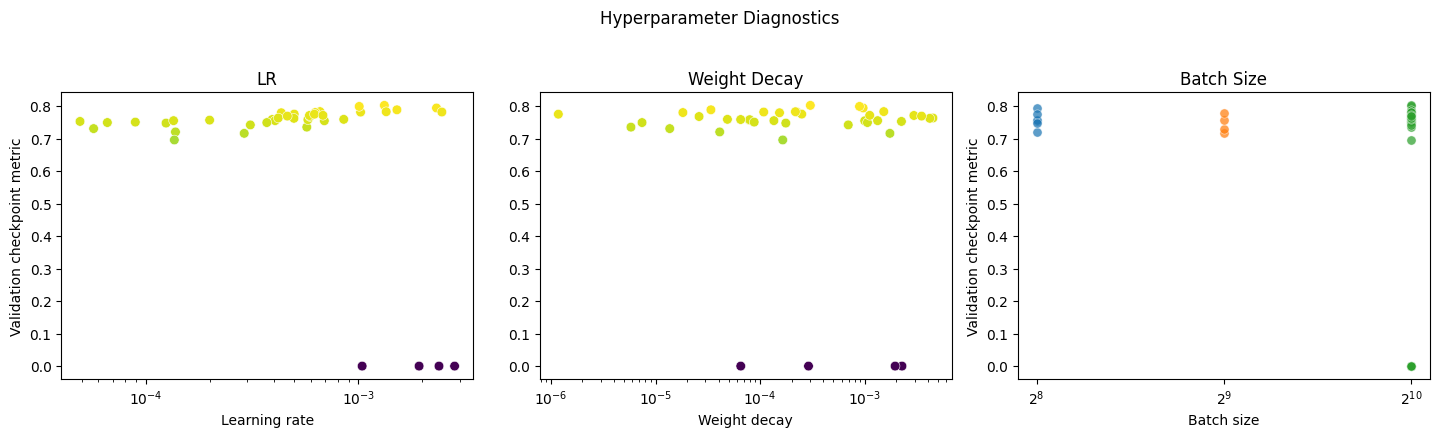

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

axes[0].scatter(hpo["lr"], hpo["best_metric_value"], c=hpo["test_r2"], cmap="viridis", s=48, edgecolor="white", linewidth=0.4)
axes[0].set_xscale("log")
axes[0].set_xlabel("Learning rate")
axes[0].set_ylabel("Validation checkpoint metric")
axes[0].set_title("LR")

axes[1].scatter(hpo["weight_decay"], hpo["best_metric_value"], c=hpo["test_r2"], cmap="viridis", s=48, edgecolor="white", linewidth=0.4)
axes[1].set_xscale("log")
axes[1].set_xlabel("Weight decay")
axes[1].set_title("Weight Decay")

if "batch_size" in hpo.columns:
    for batch_size, sub in hpo.groupby("batch_size", observed=True):
        axes[2].scatter(np.repeat(batch_size, len(sub)), sub["best_metric_value"], s=44, alpha=0.72, label=str(batch_size), edgecolor="white", linewidth=0.4)
    axes[2].set_xscale("log", base=2)
    axes[2].set_xlabel("Batch size")
    axes[2].set_title("Batch Size")
axes[2].set_ylabel("Validation checkpoint metric")

fig.suptitle("Hyperparameter Diagnostics", y=1.03)
fig.tight_layout()
fig.savefig(PLOT_DIR / "seelig_a5ss_sd1_hpo_hyperparameter_diagnostics_may2026.png", dpi=200, bbox_inches="tight")
plt.show()


## Local Summary Metrics For The Winner

The registry is enough for selection, but the local W&B summary confirms the final train/val/test metrics and per-output values for the selected scalar head.


In [14]:
def load_local_summary(run_id):
    matches = sorted(WANDB_ROOT.glob(f"run-*{run_id}/files/wandb-summary.json"))
    if not matches:
        return None, None
    return matches[0], json.loads(matches[0].read_text())

summary_path, summary = load_local_summary(validation_winner["run_id"])
print("summary_path:", summary_path)
if summary:
    keys = [
        "current_epoch", "epoch", "train_loss", "train_pearson", "train_pearson_r2", "train_spearman",
        "val_loss", "val_pearson", "val_pearson_r2", "val_spearman",
        "test_loss", "test_pearson", "test_pearson_r2", "test_spearman",
        "test_pearson_p_sd1", "test_pearson_squared_p_sd1", "test_spearman_p_sd1",
    ]
    summary_table = pd.DataFrame([{"metric": key, "value": summary.get(key)} for key in keys if key in summary])
    display(summary_table)
else:
    print("No local summary found")


summary_path: /home/minhang/synBio_AL/boda2_EU/src/learn/wandb/run-20260517_140759-hcs3zprb/files/wandb-summary.json


,metric,value
0,current_epoch,77.000000
1,epoch,78.000000
2,train_loss,0.016794
3,train_pearson,0.911504
4,train_pearson_r2,0.830840
5,train_spearman,0.805470
6,val_loss,0.019301
7,val_pearson,0.892812
8,val_pearson_r2,0.797114
9,val_spearman,0.794752


## Decision

The validation-selected run is the current canonical Seelig A5SS SD1 scalar pretrained checkpoint. It beats the literature SD1 guardrail on held-out test Pearson R2, and the same run is also the test-R2 leader among the 40 HPO runs.

Recommended next steps:

- Promote the `hcs3zprb` artifact for scalar SD1 transfer experiments.
- Run a `BassetVL` comparator before declaring `BassetBranched` intrinsically best for this scalar task.
- Add the richer 81-output donor-distribution task before treating this as a full HAL replacement; that is the task that can compare SD2, SDCRYPT, and new donor-site usage directly.


In [15]:
print("Selected run:", validation_winner["run_id"])
print("Run URL:", validation_winner["run_url"])
print("Best validation metric:", f"{validation_winner['best_metric_value']:.6f}")
print("Held-out test R2:", f"{validation_winner['test_r2']:.6f}")
print("Held-out test Pearson:", f"{validation_winner['test_pearson']:.6f}")
print("Held-out test Spearman:", f"{validation_winner['test_spearman']:.6f}")
print("Best epoch:", int(validation_winner["best_epoch"]))
print("Artifact exists:", bool(validation_winner["artifact_exists"]))
print("Artifact path:", validation_winner["artifact_path"])
print("Paper SD1 R2 guardrail:", AUTHOR_SD1_R2)
print("BODA - paper SD1 R2:", f"{validation_winner['test_r2'] - AUTHOR_SD1_R2:+.6f}")


Selected run: hcs3zprb
Run URL: https://wandb.ai/minhangxu1998-baylor-college-of-medicine/introns__seelig_2015_a5ss_sd1__scratch__basset_branched/runs/hcs3zprb
Best validation metric: 0.803168
Held-out test R2: 0.800570
Held-out test Pearson: 0.894746
Held-out test Spearman: 0.797989
Best epoch: 52
Artifact exists: True
Artifact path: /home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/introns/seelig_2015/a5ss_sd1/basset_branched/scratch_bayes/model_artifacts__introns__seelig_2015_a5ss_sd1__scratch__basset_branched__hcs3zprb__20260517_141709.tar.gz
Paper SD1 R2 guardrail: 0.75
BODA - paper SD1 R2: +0.050570
